# CS301 Project - Stage 1 (Classification)
## Heart Disease Prediction Notebook

This notebook follows the **Stage 1 order** from the project description:
1. Dataset Requirements
2. Preprocessing
3. Exploratory Data Analysis (EDA)
4. Initial Modeling (Logistic Regression)


## 1) Dataset Requirements
- Dataset must have at least 12 features
- At least 2 categorical and 2 numerical features
- Target for this notebook: `Heart Disease` (classification)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load dataset
df = pd.read_csv('../data/heart_disease_dataset.csv')

print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}): {df.columns.tolist()}')
print('\nData types:')
print(df.dtypes)

numeric_cols = ['Age', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Exercise Hours', 'Stress Level', 'Blood Sugar']
categorical_cols = ['Gender', 'Smoking', 'Family History', 'Obesity', 'Exercise Induced Angina', 'Chest Pain Type']

print('\nNumeric feature count:', len(numeric_cols))
print('Categorical feature count:', len(categorical_cols))
print('Target column: Heart Disease')

DATASET OVERVIEW
Shape: (1000, 16)
Columns (16): ['Age', 'Gender', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Smoking', 'Alcohol Intake', 'Exercise Hours', 'Family History', 'Diabetes', 'Obesity', 'Stress Level', 'Blood Sugar', 'Exercise Induced Angina', 'Chest Pain Type', 'Heart Disease']

Data types:
Age                         int64
Gender                     object
Cholesterol                 int64
Blood Pressure              int64
Heart Rate                  int64
Smoking                    object
Alcohol Intake             object
Exercise Hours              int64
Family History             object
Diabetes                   object
Obesity                    object
Stress Level                int64
Blood Sugar                 int64
Exercise Induced Angina    object
Chest Pain Type            object
Heart Disease               int64
dtype: object

Numeric feature count: 7
Categorical feature count: 6
Target column: Heart Disease


## 2) Preprocessing
Clean missing values, duplicates, and prepare the target for classification.

In [3]:
print('=' * 60)
print('PREPROCESSING / CLEANING')
print('=' * 60)

print('Missing values per column (before cleaning):')
print(df.isna().sum())

# Remove Alcohol Intake because ~1/3 rows are missing
if 'Alcohol Intake' in df.columns:
    df = df.drop(columns=['Alcohol Intake'])

dupes = df.duplicated().sum()
print('\nDuplicate rows:', dupes)

df = df.drop_duplicates()
df = df.dropna(subset=['Heart Disease'])

# Encode binary target
df = df.dropna(subset=['Heart Disease'])
df['Heart Disease'] = df['Heart Disease'].astype(int)

print('\nMissing values per column (after cleaning):')
print(df.isna().sum())
print('\nShape after cleaning:', df.shape)
print('Target distribution after cleaning:')
print(df['Heart Disease'].value_counts())

PREPROCESSING / CLEANING
Missing values per column (before cleaning):
Age                          0
Gender                       0
Cholesterol                  0
Blood Pressure               0
Heart Rate                   0
Smoking                      0
Alcohol Intake             340
Exercise Hours               0
Family History               0
Diabetes                     0
Obesity                      0
Stress Level                 0
Blood Sugar                  0
Exercise Induced Angina      0
Chest Pain Type              0
Heart Disease                0
dtype: int64

Duplicate rows: 0

Missing values per column (after cleaning):
Age                        0
Gender                     0
Cholesterol                0
Blood Pressure             0
Heart Rate                 0
Smoking                    0
Exercise Hours             0
Family History             0
Diabetes                   0
Obesity                    0
Stress Level               0
Blood Sugar                0
Exercise 

## 3) Exploratory Data Analysis (EDA)
Visualize target distribution and feature-target relationships.

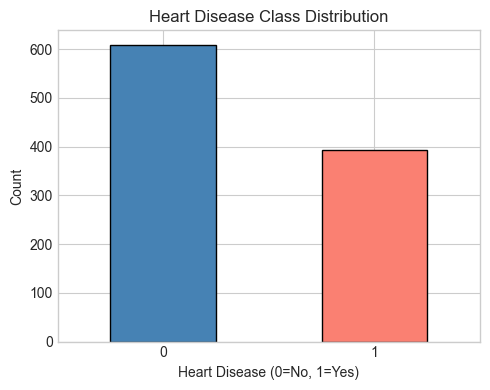

In [4]:
# Target distribution
plt.figure(figsize=(5, 4))
df['Heart Disease'].value_counts().sort_index().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Heart Disease Class Distribution')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

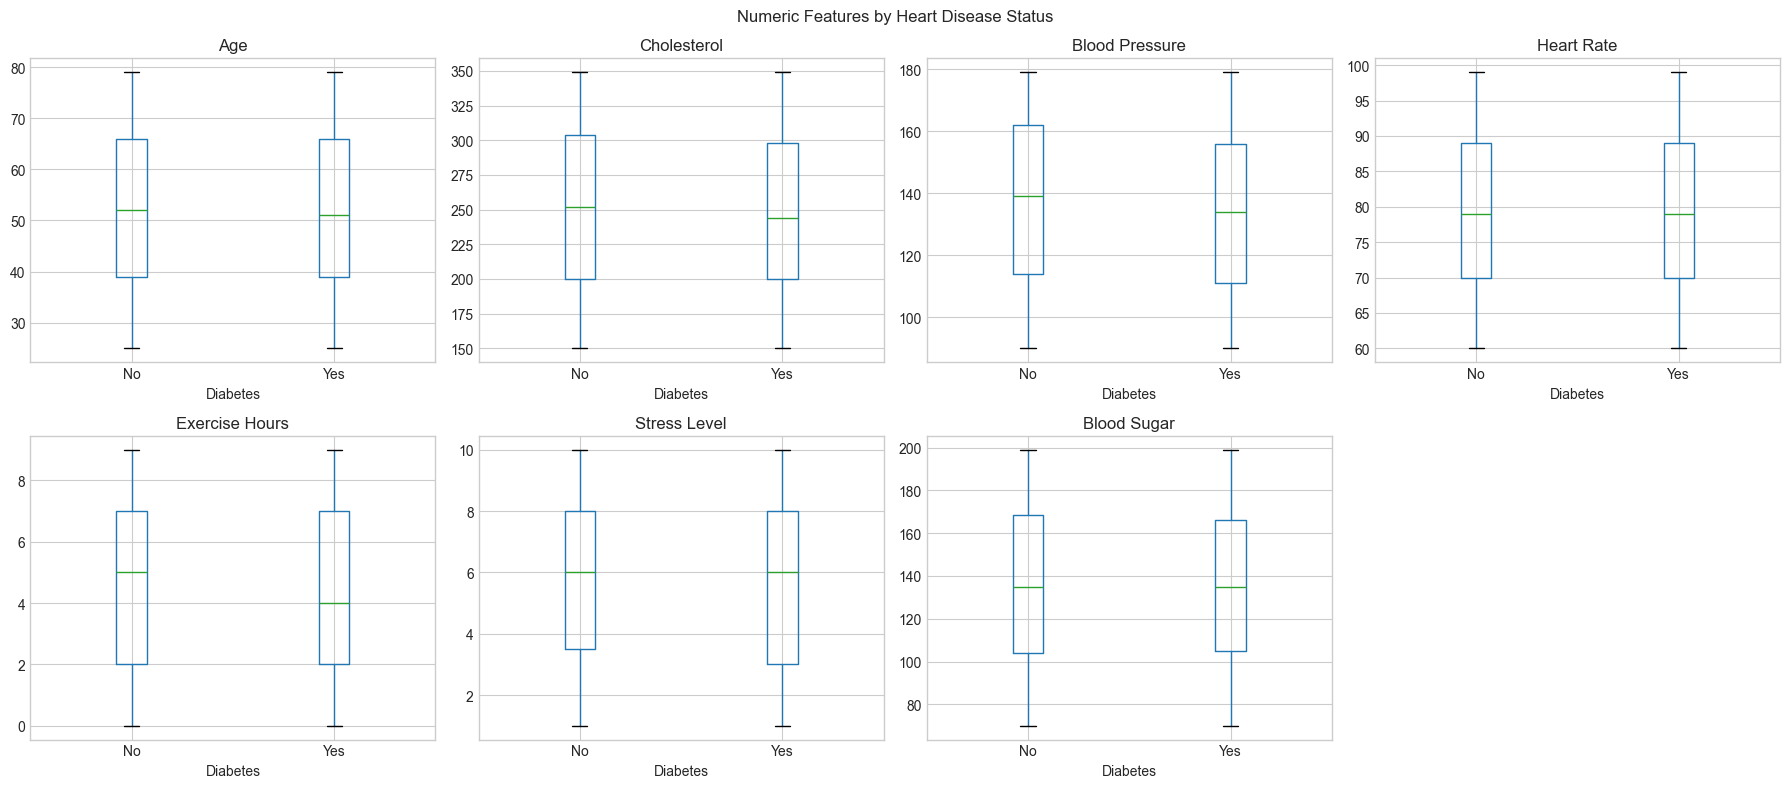

In [5]:
# Numeric features vs target
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='Diabetes', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Diabetes')
axes[-1].set_visible(False)
plt.suptitle('Numeric Features by Heart Disease Status')
plt.tight_layout()
plt.show()

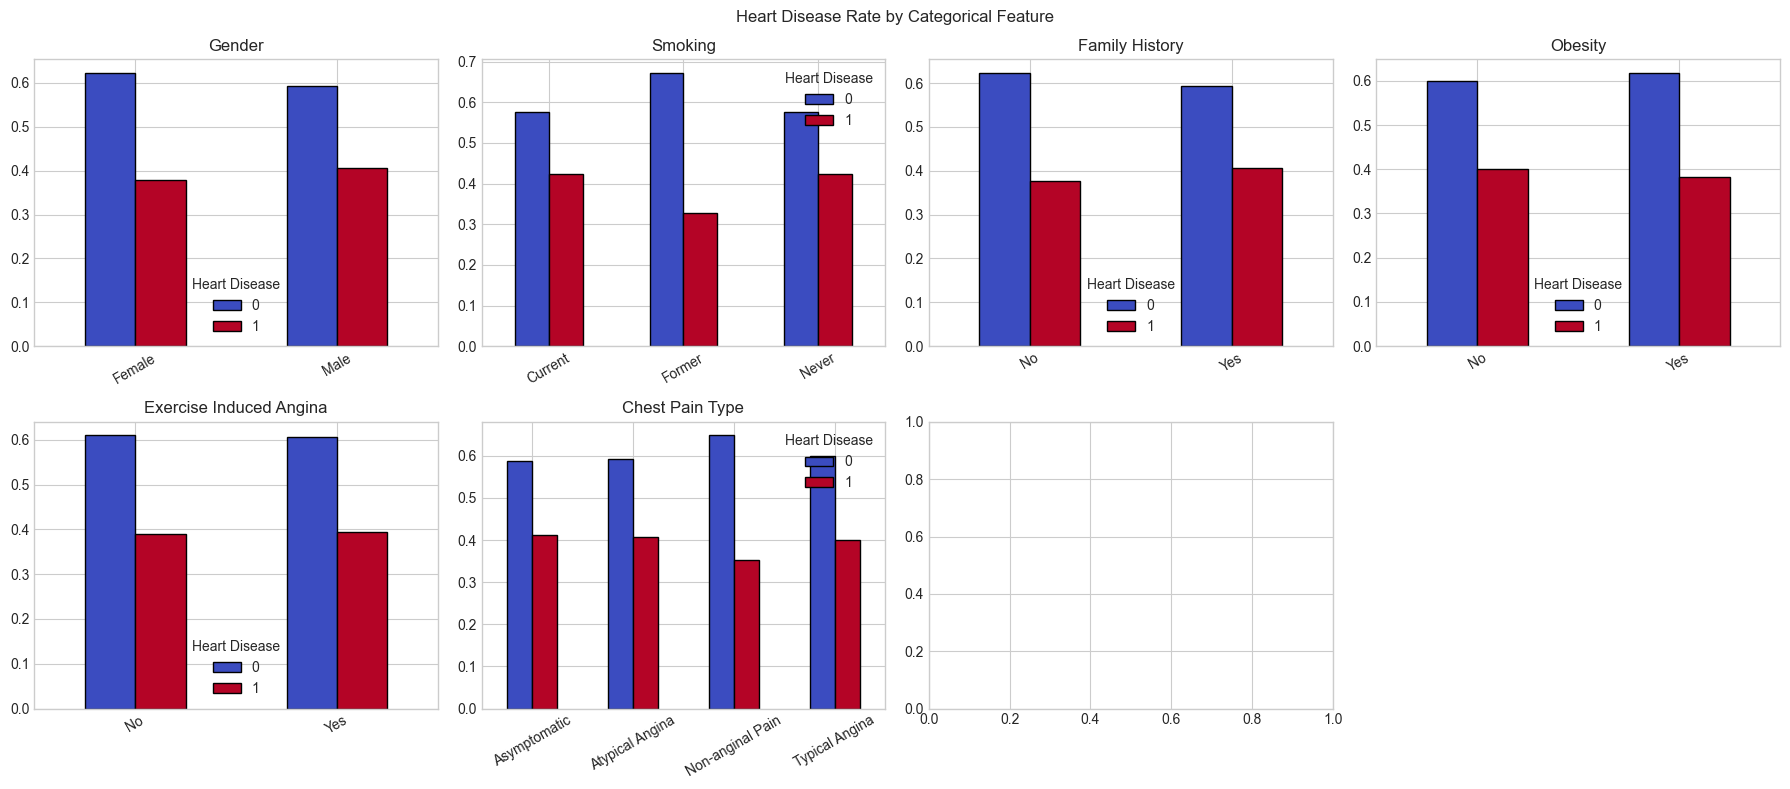

In [6]:
# Categorical features vs target
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['Heart Disease'], normalize='index')
    ct.plot(kind='bar', ax=axes[i], colormap='coolwarm', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
axes[-1].set_visible(False)
plt.suptitle('Heart Disease Rate by Categorical Feature')
plt.tight_layout()
plt.show()

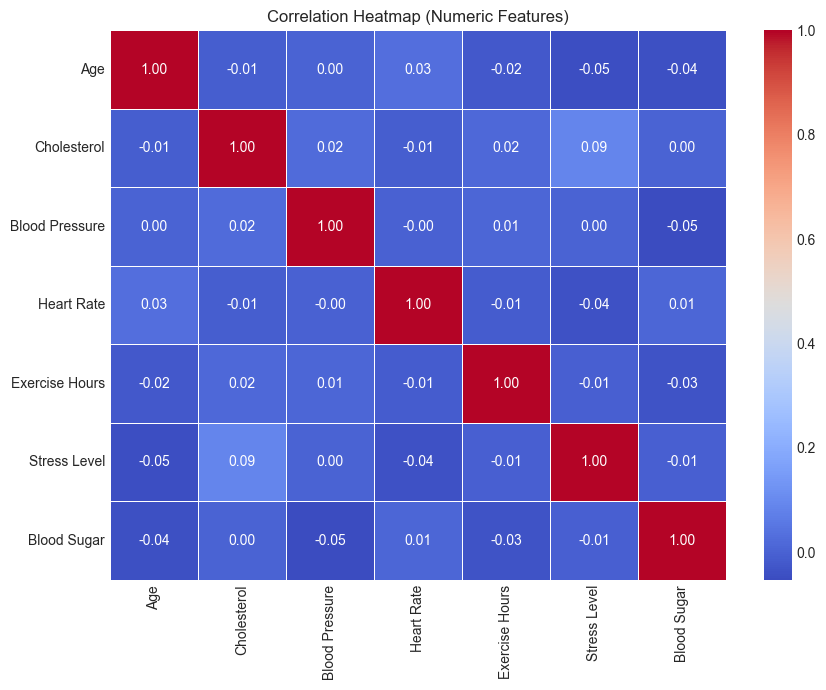

In [7]:
# Correlation heatmap for numeric features
plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

## 4) Initial Modeling (Classification)
Train a Logistic Regression classifier and evaluate with **Accuracy** and **F1-score**.

In [8]:
selected_numeric = numeric_cols.copy()
selected_categorical = categorical_cols.copy()

print('Selected numeric features:', selected_numeric)
print('Selected categorical features:', selected_categorical)

Selected numeric features: ['Age', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Exercise Hours', 'Stress Level', 'Blood Sugar']
Selected categorical features: ['Gender', 'Smoking', 'Family History', 'Obesity', 'Exercise Induced Angina', 'Chest Pain Type']


In [10]:
# Build model dataset
df_model = df[selected_numeric + selected_categorical + ['Heart Disease']].copy()

X = df_model.drop(columns=['Heart Disease'])
y = df_model['Heart Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), selected_numeric),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), selected_categorical),
    ]
)

model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'F1-score: {f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Heart Disease', 'Heart Disease']))

Accuracy: 0.8500
F1-score: 0.8148

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.90      0.85      0.87       122
   Heart Disease       0.79      0.85      0.81        78

        accuracy                           0.85       200
       macro avg       0.84      0.85      0.84       200
    weighted avg       0.85      0.85      0.85       200



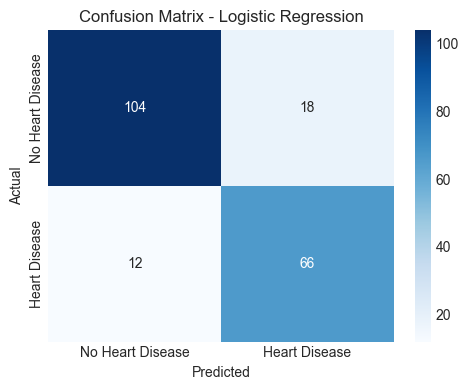

In [11]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()